<a href="https://colab.research.google.com/github/Shahana023/cse-resources/blob/main/ml_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Original Label: 7
Adversarial Prediction: 702


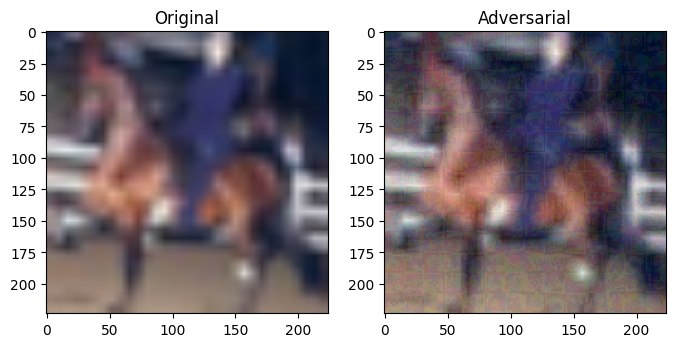

In [ ]:
!pip install torch torchvision timm matplotlib opencv-python
!pip install foolbox advertorch
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import timm
from advertorch.attacks import FGSM

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)
model = timm.create_model('vit_base_patch16_224', pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

images, labels = next(iter(trainloader))
images = images.to(device)
labels = labels.to(device)

attack = FGSM(model, eps=0.03)
adv_images = attack.perturb(images, labels)

with torch.no_grad():
    output_adv = model(adv_images)
    pred_adv = output_adv.argmax(dim=1)

success_rate = (pred_adv != labels).float().mean().item()
print(f"Attack success rate: {success_rate:.4f}")

orig = images[0].cpu()
adv = adv_images[0].cpu()
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
orig_disp = torch.clamp(orig * std + mean, 0, 1)
adv_disp = torch.clamp(adv * std + mean, 0, 1)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(orig_disp.permute(1,2,0))
plt.title("Original")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(adv_disp.permute(1,2,0))
plt.title("Adversarial")
plt.axis('off')
plt.show()

torch.save(model.state_dict(), "model.pth")
plt.imsave("adv_image.png", adv_disp.permute(1,2,0).numpy())


In [ ]:
# Model and adversarial image are already saved in the previous cell.

In [ ]:
# --- ORIGINAL CODE (backup) ---
!pip install torch torchvision timm matplotlib opencv-python
!pip install foolbox advertorch
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import timm
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)
model = timm.create_model('vit_base_patch16_224', pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
images, labels = next(iter(trainloader))

image = images[0].unsqueeze(0).to(device)
label = labels[0].to(device)
image.requires_grad = True

output = model(image)

loss = torch.nn.functional.cross_entropy(output, label.unsqueeze(0))

model.zero_grad()
loss.backward()

epsilon = 0.03

data_grad = image.grad.data

perturbed_image = image + epsilon * data_grad.sign()

perturbed_image = torch.clamp(perturbed_image, 0, 1)
output_adv = model(perturbed_image)

final_pred = output_adv.max(1, keepdim=True)[1]

print("Original Label:", label.item())
print("Adversarial Prediction:", final_pred.item())
orig = image.squeeze().detach().cpu().permute(1,2,0)
adv = perturbed_image.squeeze().detach().cpu().permute(1,2,0)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(adv)
plt.title("Adversarial")

plt.show()

In [ ]:
# --- IMPROVED ATTACK (normalization + advertorch FGSM) ---
!pip install torch torchvision timm matplotlib opencv-python
!pip install foolbox advertorch
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import timm
from advertorch.attacks import FGSM

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)
model = timm.create_model('vit_base_patch16_224', pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

images, labels = next(iter(trainloader))
images = images.to(device)
labels = labels.to(device)

attack = FGSM(model, eps=0.03)
adv_images = attack.perturb(images, labels)

with torch.no_grad():
    output_adv = model(adv_images)
    pred_adv = output_adv.argmax(dim=1)

success_rate = (pred_adv != labels).float().mean().item()
print(f"Attack success rate: {success_rate:.4f}")

orig = images[0].cpu()
adv = adv_images[0].cpu()
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
orig_disp = torch.clamp(orig * std + mean, 0, 1)
adv_disp = torch.clamp(adv * std + mean, 0, 1)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(orig_disp.permute(1,2,0))
plt.title("Original")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(adv_disp.permute(1,2,0))
plt.title("Adversarial")
plt.axis('off')
plt.show()

torch.save(model.state_dict(), "model.pth")
plt.imsave("adv_image.png", adv_disp.permute(1,2,0).numpy())